# 05 - Variational Quantum Classifier (VQC)

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Builds a **Feature Map -> Ansatz -> Variational Quantum Classifier (VQC)** pipeline,
visualizes the full circuit, trains it on a toy dataset while recording the optimizer's
convergence trace, and evaluates the result.

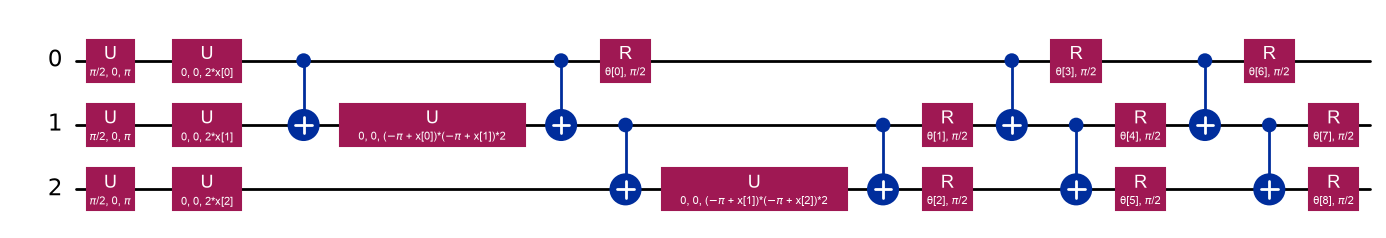

In [2]:
from src.quantum.feature_maps import build_feature_map
from src.quantum.ansatzes import build_ansatz

feature_map = build_feature_map("zz", num_qubits=3, reps=1, entanglement="linear")
ansatz = build_ansatz("real_amplitudes", num_qubits=3, reps=2, entanglement="linear")
full_circuit = feature_map.compose(ansatz)

fig = full_circuit.decompose().draw("mpl", style="iqp")
fig.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\05_vqc_circuit.png", bbox_inches="tight")
fig


In [3]:
import numpy as np
from src.quantum.vqc_model import VQCModel
from src.evaluation.metrics import compute_metrics

rng = np.random.default_rng(2)
X = rng.normal(size=(50, 3))
y = (X[:, 0] + X[:, 1] > 0).astype(int)
X_train, y_train = X[:35], y[:35]
X_test, y_test = X[35:], y[35:]

vqc = VQCModel(num_qubits=3, feature_map_reps=1, ansatz_reps=2, backend="simulator",
               shots=256, seed=42, optimizer="cobyla", optimizer_maxiter=40)
fit_result = vqc.fit(X_train, y_train)
print(fit_result)


QuantumFitResult(training_time_s=8.34760959999403, n_train=35, num_qubits=3, circuit_depth=15, transpiled_depth=26, shots=256, backend_name='aer_simulator', optimizer='cobyla', final_objective_value=0.9833893893660004)


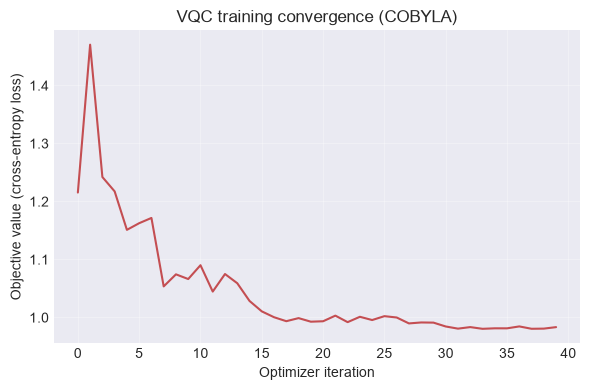

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(vqc._objective_values, color="#C44E52")
ax.set_xlabel("Optimizer iteration")
ax.set_ylabel("Objective value (cross-entropy loss)")
ax.set_title("VQC training convergence (COBYLA)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\05_vqc_convergence.png")
plt.show()


In [5]:
proba = vqc.predict_proba(X_test)
m = compute_metrics(y_test, proba, threshold=0.5)
print(f"PR-AUC={m.pr_auc:.3f}  ROC-AUC={m.roc_auc:.3f}  Recall={m.recall:.3f}  Precision={m.precision:.3f}  FPR={m.fpr:.3f}")
pd.DataFrame([m.to_dict()]).T.rename(columns={0: "value"})


PR-AUC=0.624  ROC-AUC=0.527  Recall=0.500  Precision=0.571  FPR=0.429


,value
pr_auc,0.623922
roc_auc,0.526786
average_precision,0.635218
precision,0.571429
recall,0.500000
f1,0.533333
fpr,0.428571
fnr,0.500000
mcc,0.071429
brier_score,0.263986
